# Word 2 Vector


## Installing Required Libraries


In [2]:
import sys
import subprocess
import importlib.util

package_name = 'gensim'

if importlib.util.find_spec(package_name) is None:
    print(f"Installing {package_name}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
else:
    print(f"{package_name} is already installed. Skipping.")

Installing gensim...


## Importing Libraries


In [ ]:
import pandas as pd
import numpy as np
import gensim.downloader as api
import nltk
from nltk import sent_tokenize
from gensim.utils import simple_preprocess
import gensim

In [ ]:
nltk.download('punkt_tab')

## Downloading the Model


In [3]:
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


## Model Functionality


In [4]:
model

### Model Shape


In [6]:
model['cricket'].shape

(300,)

### Most Similar Words


In [11]:
vector = model['cricket'] - model['ICC'] 

In [12]:
model.most_similar([vector])

[('cricket', 0.48237335681915283),
 ('rugby', 0.37614017724990845),
 ('netball', 0.36047419905662537),
 ('cricketer', 0.34985822439193726),
 ('shinty', 0.3495470881462097),
 ('windswept_moors', 0.3484535813331604),
 ('hockey', 0.348192423582077),
 ('footy', 0.34454795718193054),
 ('Twenty##_cricket', 0.34404256939888),
 ('cricketing', 0.3430434465408325)]

In [15]:
vector = model['laptop'] - model['Apple'] + model['Microsoft']
model.most_similar([vector])

[('laptop', 0.666688859462738),
 ('laptops', 0.5631785988807678),
 ('PCs', 0.5475146770477295),
 ('Microsoft', 0.546826958656311),
 ('laptop_computer', 0.5337494015693665),
 ('Windows_XP', 0.5271022915840149),
 ('computer', 0.5184600949287415),
 ('desktop', 0.5098012089729309),
 ('computers', 0.5086804032325745),
 ('Windows_XP_Professional', 0.5086702704429626)]

In [17]:
vector = model['cricket']
model.most_similar([vector])

[('cricket', 1.0),
 ('cricketing', 0.8372225761413574),
 ('cricketers', 0.8165745735168457),
 ('Test_cricket', 0.8094819188117981),
 ('Twenty##_cricket', 0.8068488240242004),
 ('Twenty##', 0.7624265551567078),
 ('Cricket', 0.75413978099823),
 ('cricketer', 0.7372578382492065),
 ('twenty##', 0.7316356897354126),
 ('T##_cricket', 0.7304613590240479)]

In [42]:
vector = model['King'] - model['Queen'] + model['Prince']
model.most_similar([vector])

[('Prince', 0.766902506351471),
 ('King', 0.5902578234672546),
 ('Jackson', 0.44770902395248413),
 ('Saunders', 0.4310215711593628),
 ('Lewis', 0.4127529561519623),
 ('Muhammad', 0.3998025357723236),
 ('O._Snowden', 0.3857314884662628),
 ('Lomax', 0.38431626558303833),
 ('LUCEDALE', 0.3825432360172272),
 ('Thurston', 0.3772961497306824)]

In [43]:
vector = model['laptop'] - model['keyboard']
model.most_similar([vector])

[('laptop', 0.39274120330810547),
 ('laptops', 0.3712317943572998),
 ('laptop_computers', 0.34751367568969727),
 ('laptop_computer', 0.34073230624198914),
 ('computers', 0.29115891456604004),
 ('notebook_computers', 0.28970232605934143),
 ('Laptops', 0.27772095799446106),
 ('bootlegged_DVDs', 0.2728985846042633),
 ('counterfeit_DVDs', 0.26741984486579895),
 ('Elmostafa', 0.26251691579818726)]

### Similarity Score


In [19]:
model.similarity("man","woman")

np.float32(0.76640123)

In [20]:
model.similarity("man", "violence")

np.float32(0.06061824)

In [21]:
model.similarity("woman", "violence")

np.float32(0.14214475)

In [22]:
model.similarity('boys', 'torture')

np.float32(0.12203576)

In [23]:
model.similarity('girls', 'torture')

np.float32(0.14838627)

In [41]:
model.similarity('boys','girls')

np.float32(0.8766965)

### Word Does Not Match with Others


In [24]:
model.doesnt_match(['Pakistan','India','England'])

'England'

In [25]:
model.doesnt_match(['Pakistan','USA','England'])

'USA'

In [26]:
model.doesnt_match(['Pakistan','Australia','England'])

'Pakistan'

In [27]:
model.doesnt_match(['Karachi', 'Lahore', 'Delhi'])

'Delhi'

In [45]:
np.max(model['play'])

np.float32(0.42382812)

In [46]:
np.min(model['play'])

np.float32(-0.3515625)

## Word2Vector on Game Of Thrones Books Dataset


### Loading Dataset


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download('khulasasndh/game-of-thrones-books')

100%|██████████| 3.71M/3.71M [00:00<00:00, 141MB/s]

Extracting files...


### Coombining text files and change to sentence token and apply gensim model simple preprocess


In [49]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [50]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    cleaned_text = [word for word in text.split() if word not in stop_words]
    return ' '.join(cleaned_text)

In [81]:
story = []
for i in range(1,6):
    file = f'{dataset_path}/00{i}ssb.txt'
    with open(file, 'r', encoding='latin-1') as f:
        text = f.read()
    text = remove_stopwords(text)
    tokens = sent_tokenize(text)
    for token in tokens:
        story.append(simple_preprocess(token))

In [82]:
len(story)

145073

### Creating model object


In [83]:
model = gensim.models.Word2Vec(
    window=10, min_count=2
)

### Building model vocab


In [84]:
model.build_vocab(story)

### Training Model


In [85]:
model.train(story, total_examples=model.corpus_count, epochs=model.epochs)

(4996027, 5308310)

### Testing Model


In [86]:
model.wv.most_similar('daenerys')

[('stormborn', 0.8639474511146545),
 ('targaryen', 0.8363823294639587),
 ('unburnt', 0.8212113380432129),
 ('myrcella', 0.8139547109603882),
 ('dorne', 0.8124120235443115),
 ('elia', 0.8109958171844482),
 ('princess', 0.8025563359260559),
 ('queen', 0.7991440296173096),
 ('viserys', 0.7634642124176025),
 ('trystane', 0.7607623934745789)]

In [87]:
model.wv.get_mean_vector(model.wv.index_to_key)

array([-0.08255283,  0.09935867,  0.07689   ,  0.08675086, -0.09084652,
       -0.11330275, -0.07944085,  0.24757001, -0.00986866, -0.02955722,
       -0.10187267, -0.13001247, -0.0401023 , -0.002114  , -0.09926648,
       -0.05120292,  0.07050067, -0.11870852, -0.03850942, -0.2161201 ,
       -0.02119363,  0.03850809,  0.03570806, -0.01331694,  0.0082257 ,
        0.00796185, -0.08854592, -0.08923877, -0.04314811,  0.08563292,
        0.05016638,  0.01563758, -0.02688544, -0.02241815, -0.09490389,
        0.14916395,  0.04800238, -0.069442  ,  0.0198621 , -0.17639248,
        0.0014395 , -0.03947726, -0.07195293, -0.079179  ,  0.074632  ,
       -0.09176142, -0.08725549, -0.02739716,  0.02981367,  0.11796385,
        0.07085486, -0.06827405, -0.03246157,  0.005532  , -0.00919867,
        0.03004162,  0.00561799,  0.00637982, -0.06343576,  0.08668621,
        0.04541025,  0.0632405 , -0.00089966, -0.00551546, -0.13849927,
        0.03501062,  0.03347783,  0.06335896, -0.06913359,  0.07

In [88]:
y = model.wv.index_to_key

In [90]:
len(y)

17452

In [91]:
model.wv.doesnt_match(['jon','robb','arya','sansa','bran'])

'jon'

In [92]:
model.wv.doesnt_match(['cersei','jaime','bronn','tyrion'])

'bronn'

In [93]:
model.wv['jon']

array([-0.94819987,  2.1711    ,  0.98942614,  2.8059385 , -0.89051473,
       -0.4483616 , -0.9923505 ,  0.34696195,  0.14262049, -1.2643238 ,
       -0.02176184, -0.02729587,  0.39421728,  0.51978314, -3.1206903 ,
       -1.4008335 ,  2.6118536 , -1.3028504 ,  0.9812109 , -0.15591611,
        0.33842948, -1.7746612 , -0.24667372,  1.6271821 ,  1.4246669 ,
        0.88846827, -0.265326  ,  1.1914259 ,  1.5932317 ,  1.2170746 ,
        0.75144964, -1.1871164 ,  0.84673786, -1.525024  ,  0.5814525 ,
        0.6089997 ,  2.759829  , -0.22782345,  0.06983186, -0.48440105,
       -0.4427501 ,  0.91134506,  0.32125962, -0.81744   , -0.6252409 ,
       -0.37890986,  0.12005115, -0.80804634, -0.48441806,  0.11191713,
        0.35130182, -0.28182325, -3.245626  ,  1.4453932 , -1.2944605 ,
       -0.6526102 ,  0.24162577, -0.18977213, -0.78552467, -0.87341434,
       -0.53911865,  1.1512322 , -0.5429902 ,  1.5242584 ,  0.5592236 ,
        0.472271  ,  1.633714  ,  0.53210664, -0.14109233, -0.72

In [94]:
model.wv.similarity('arya','sansa')

np.float32(0.8027612)

In [95]:
model.wv.get_normed_vectors()

array([[-0.05268084, -0.0409356 ,  0.10532518, ..., -0.03869402,
        -0.15639472,  0.10299876],
       [-0.11123134,  0.06506853,  0.11116882, ..., -0.07059655,
        -0.07222272,  0.05853854],
       [ 0.01612884,  0.05614537, -0.10827462, ...,  0.09287075,
         0.09635346, -0.11916398],
       ...,
       [-0.0736042 ,  0.1417473 ,  0.01179383, ..., -0.18631794,
        -0.03618715,  0.05319402],
       [ 0.00779081,  0.11484651,  0.01330022, ..., -0.0927934 ,
        -0.10424083,  0.05254711],
       [ 0.01433522,  0.0737143 , -0.00207147, ...,  0.02838434,
         0.13152064, -0.03154142]], dtype=float32)

### Model Words Vector Representation shape


In [96]:
model.wv.get_normed_vectors().shape

(17452, 100)

### Reducing Vectors Dimension to Visualize Data


In [97]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

In [103]:
X = pca.fit_transform(model.wv.get_normed_vectors())

In [104]:
X.shape

(17452, 2)

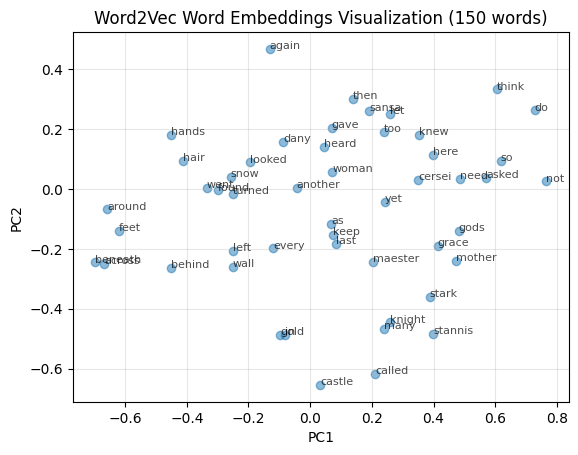

In [117]:
import matplotlib.pyplot as plt

# Plot only first 150 words for faster visualization

plt.scatter(X[100:150, 0], X[100:150, 1], alpha=0.5)

# Add labels for each point
for i, word in enumerate(y[100:150]):
    plt.annotate(word, (X[100+i, 0], X[100+i, 1]), fontsize=8, alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Word2Vec Word Embeddings Visualization (150 words)')
plt.grid(True, alpha=0.3)
plt.show()